# Módulo 10 tarefa 2

Considere a mesma base de dados utilizada na tarefa 1 ```previsao_de_renda.csv```.

1) Com o que você viu em aula, faça uma análise das variáveis qualitativas (posse de imóvel e posse de veículo) para verificar se são boas preditoras de *renda*. Alguma delas parece discriminar *renda* de forma estatisticamente significante?

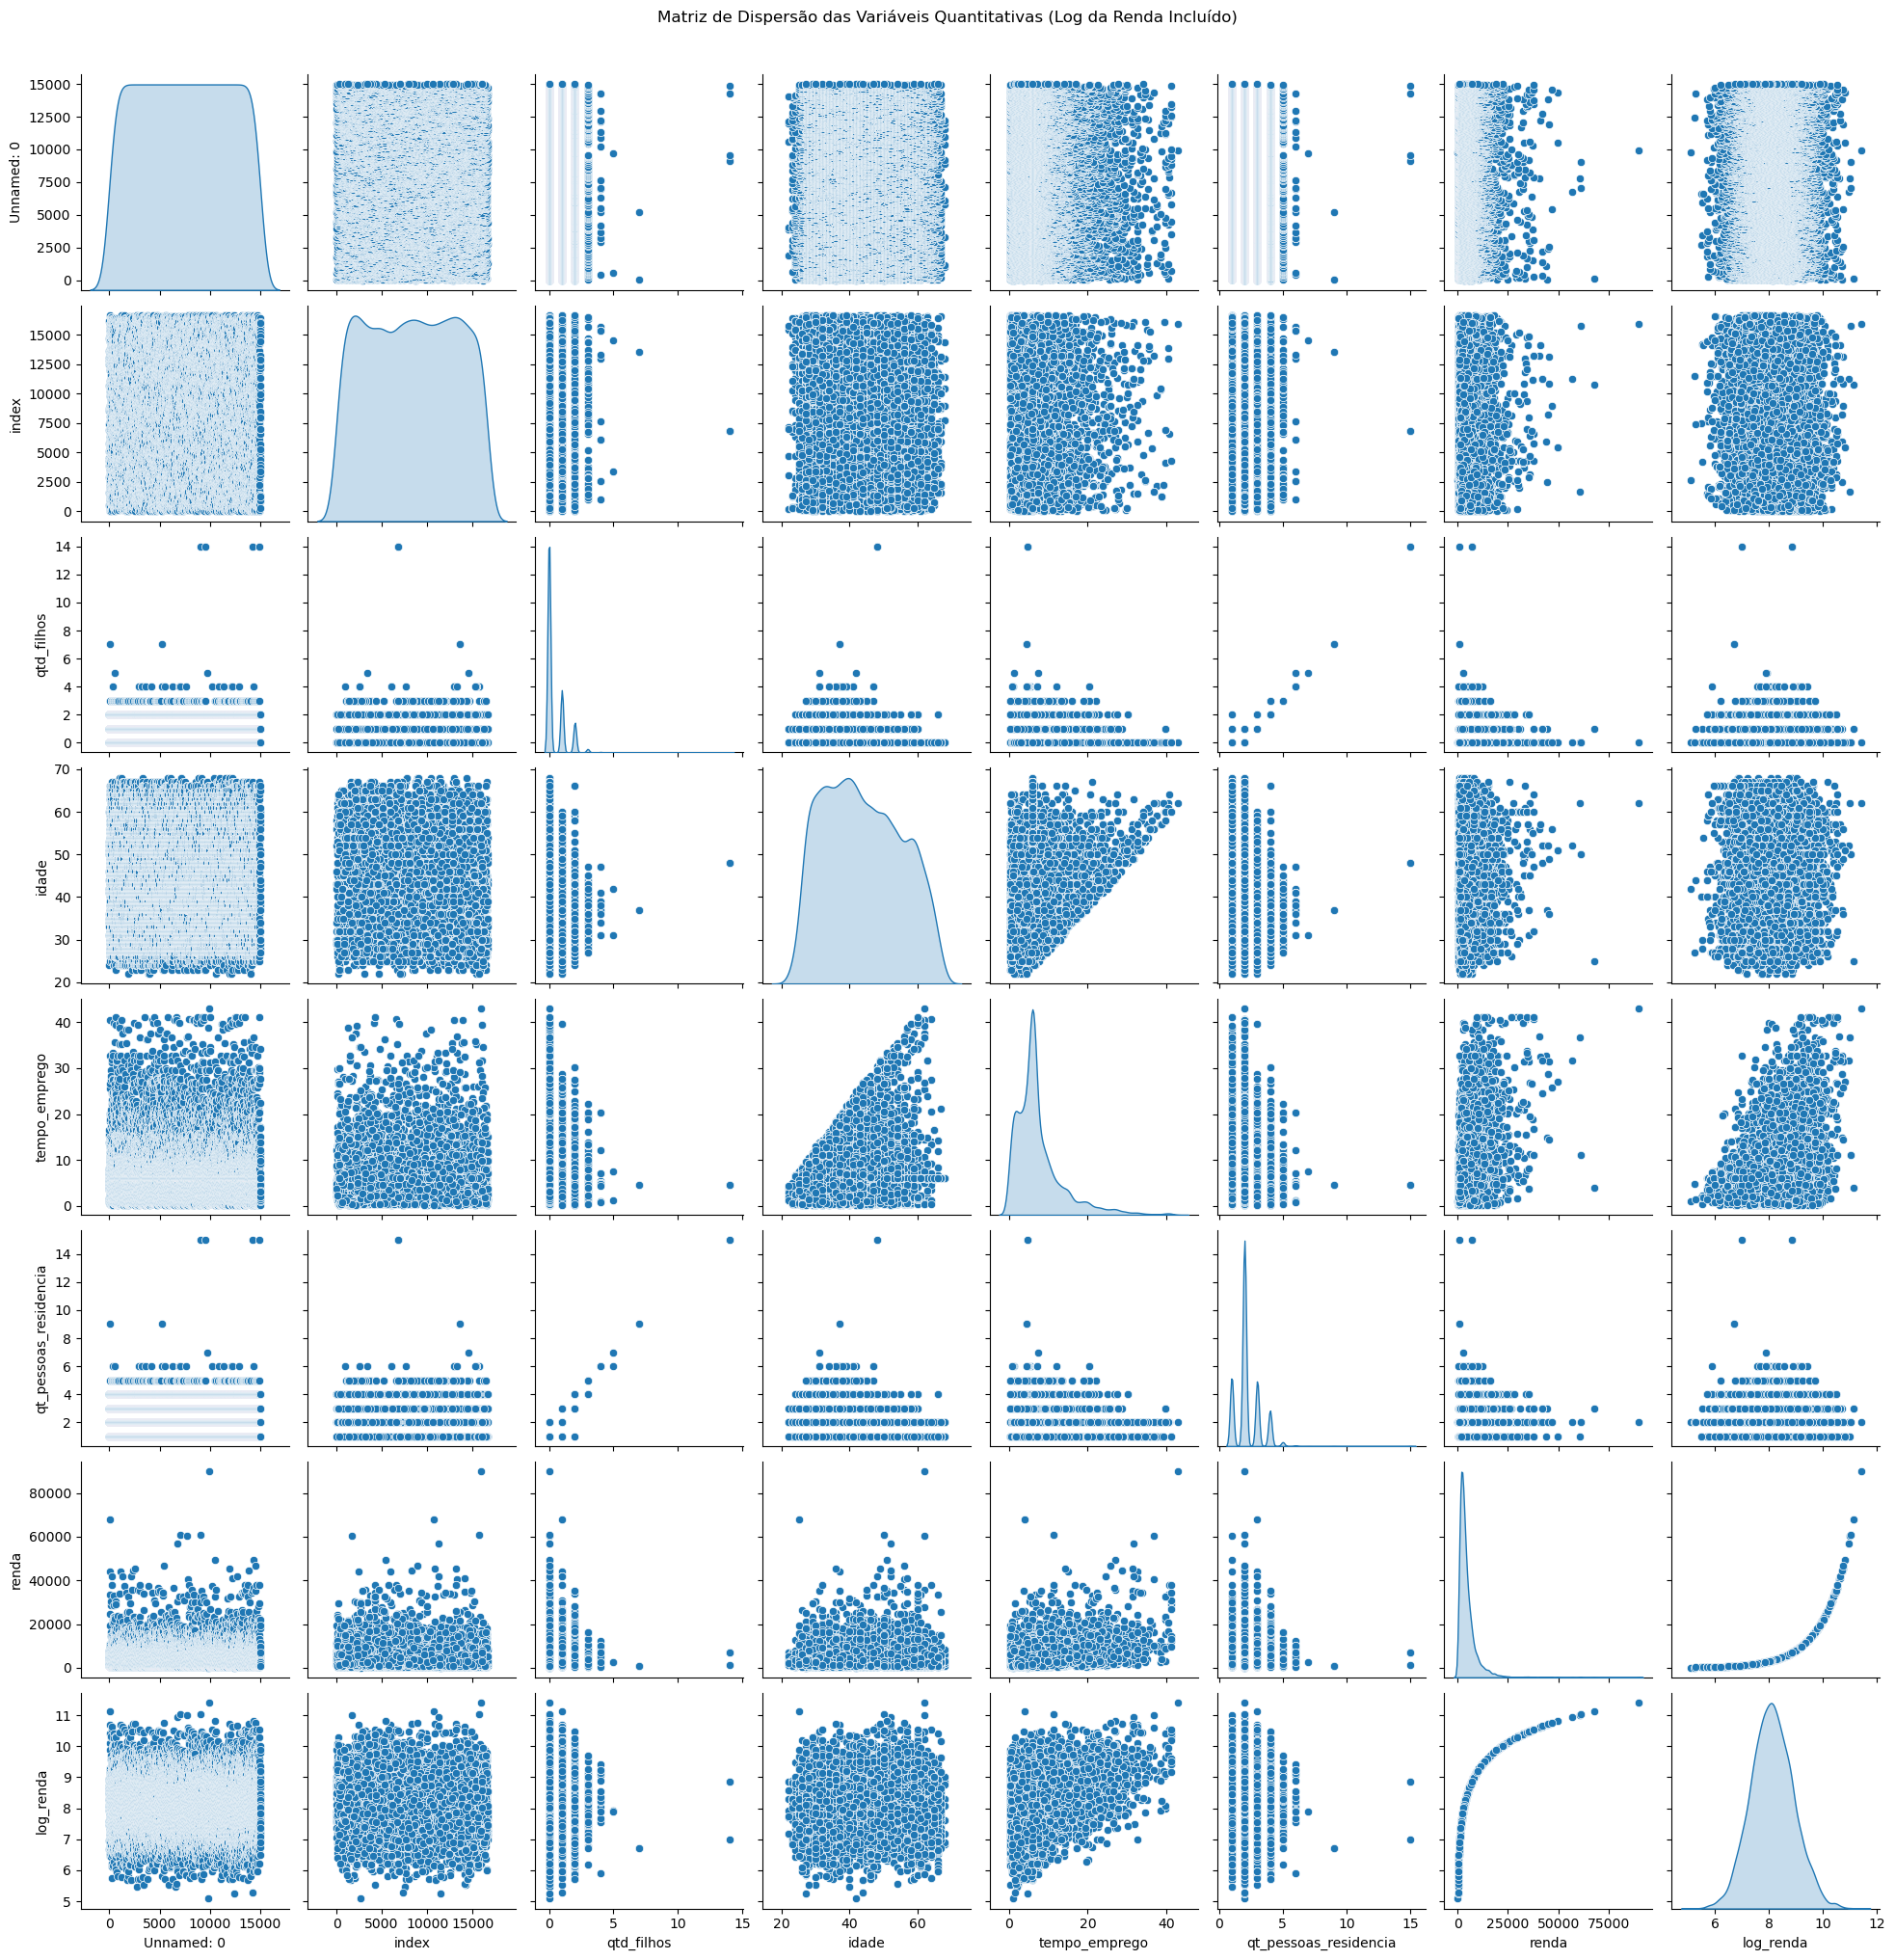

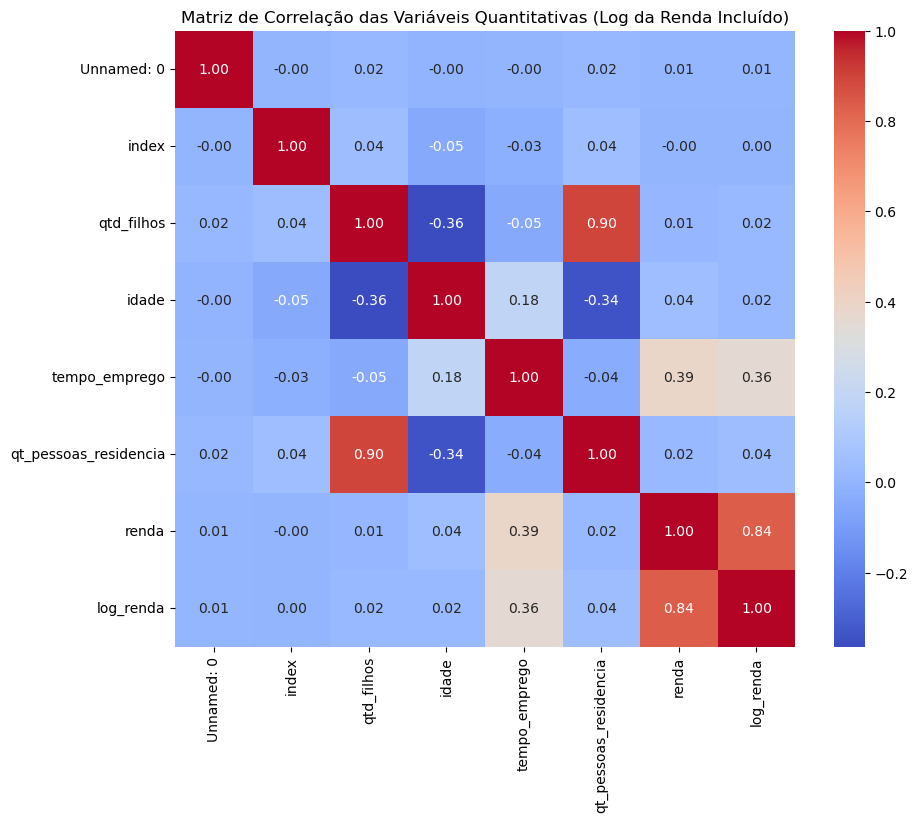

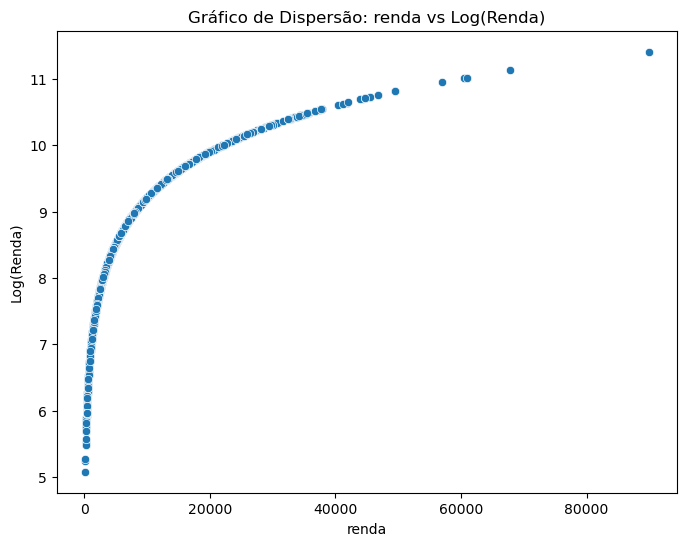

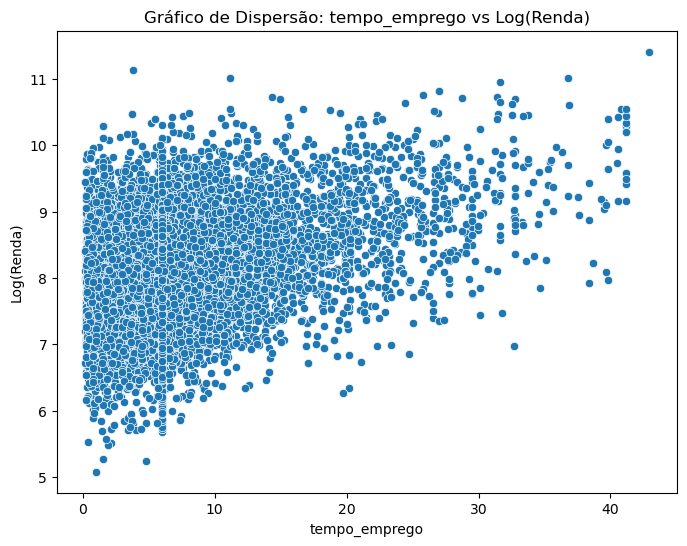

C:\Users\fabio.stampone\AppData\Local\Temp\ipykernel_4320\2812307291.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  qualitative_data['log_renda'] = np.log1p(qualitative_data['renda'])


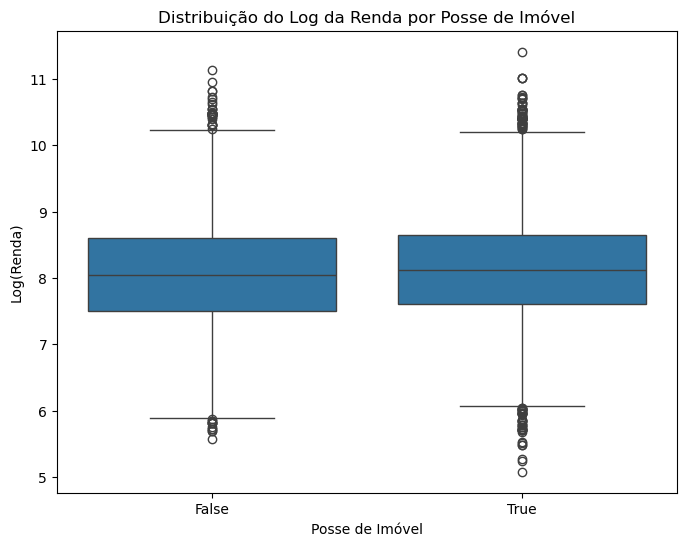

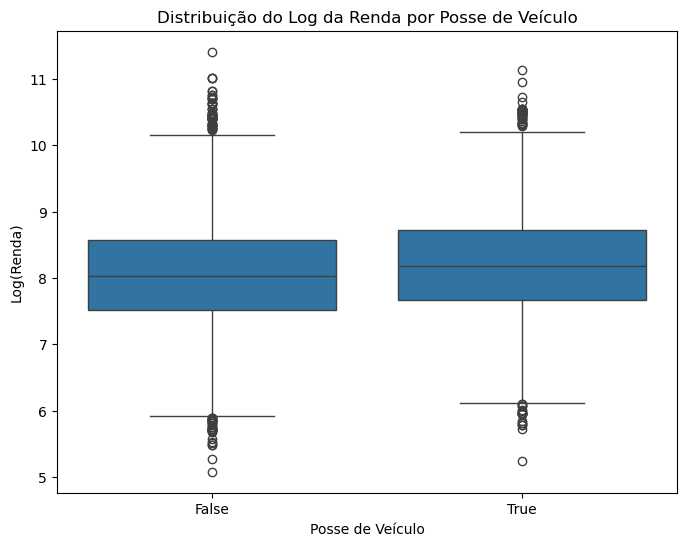

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

df = pd.read_csv ('C://Users/fabio.stampone/Documents/EBAC/Mod10/Pratique2/Base.csv')

# Selecionar variáveis quantitativas
quantitative_data = df.select_dtypes(include=['float64', 'int64'])

# Tratar valores ausentes preenchendo com a mediana
quantitative_data = quantitative_data.fillna(quantitative_data.median())

# Calcular o logaritmo da variável 'renda'
quantitative_data['log_renda'] = np.log1p(quantitative_data['renda'])

# Criar a matriz de dispersão com 'log_renda'
sns.pairplot(quantitative_data, diag_kind="kde")
plt.suptitle("Matriz de Dispersão das Variáveis Quantitativas (Log da Renda Incluído)", y=1.02)
plt.show()

# Calcular a matriz de correlação com 'log_renda'
correlation_matrix = quantitative_data.corr()

# Plotar o mapa de calor da matriz de correlação com 'log_renda'
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlação das Variáveis Quantitativas (Log da Renda Incluído)")
plt.show()

# Identificar as duas variáveis mais correlacionadas com 'log_renda'
top_correlated = correlation_matrix['log_renda'].sort_values(ascending=False).index[1:3]

# Plotar gráfico de dispersão para as duas variáveis mais correlacionadas com 'log_renda'
plt.figure(figsize=(8, 6))
sns.scatterplot(data=quantitative_data, x=top_correlated[0], y='log_renda')
plt.title(f"Gráfico de Dispersão: {top_correlated[0]} vs Log(Renda)")
plt.xlabel(top_correlated[0])
plt.ylabel("Log(Renda)")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=quantitative_data, x=top_correlated[1], y='log_renda')
plt.title(f"Gráfico de Dispersão: {top_correlated[1]} vs Log(Renda)")
plt.xlabel(top_correlated[1])
plt.ylabel("Log(Renda)")
plt.show()

# Analisar variáveis qualitativas: posse de imóvel e posse de veículo
qualitative_data = df[['posse_de_imovel', 'posse_de_veiculo', 'renda']]
qualitative_data['log_renda'] = np.log1p(qualitative_data['renda'])

# Comparar distribuição de renda para posse de imóvel
plt.figure(figsize=(8, 6))
sns.boxplot(data=qualitative_data, x='posse_de_imovel', y='log_renda')
plt.title("Distribuição do Log da Renda por Posse de Imóvel")
plt.xlabel("Posse de Imóvel")
plt.ylabel("Log(Renda)")
plt.show()

# Comparar distribuição de renda para posse de veículo
plt.figure(figsize=(8, 6))
sns.boxplot(data=qualitative_data, x='posse_de_veiculo', y='log_renda')
plt.title("Distribuição do Log da Renda por Posse de Veículo")
plt.xlabel("Posse de Veículo")
plt.ylabel("Log(Renda)")
plt.show()


In [ ]:
Ambas as variáveis, posse_de_imovel e posse_de_veiculo, discriminam a renda de forma estatisticamente significativa. 
A posse de veículo parece ter uma relação ainda mais forte com a renda, dada a magnitude maior da estatística t e o valor p extremamente baixo.